<a href="https://colab.research.google.com/github/Michele-Bufis/Ecg-cnn-embedded/blob/main/ClassificazionePatologieECGconCNNEmbedded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificazione Patologie ECG con CNN Embedded
### Tentativo 7: pipeline gerarchica + tutte le tecniche combinate

**Stadio 1**: N vs Anomalo (con RR interval)
**Stadio 2**: S/V/F/Q su soli anomali (con RR interval + augmentation su F + monitoraggio Macro F1)

## 0. Avvio rapido (richiede salvataggio con RR interval)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'

X_train = np.load(f'{SALVA_DIR}/X_train.npy')
y_train = np.load(f'{SALVA_DIR}/y_train.npy')
rr_train = np.load(f'{SALVA_DIR}/rr_train.npy')
X_val = np.load(f'{SALVA_DIR}/X_val.npy')
y_val = np.load(f'{SALVA_DIR}/y_val.npy')
rr_val = np.load(f'{SALVA_DIR}/rr_val.npy')
X_test = np.load(f'{SALVA_DIR}/X_test.npy')
y_test = np.load(f'{SALVA_DIR}/y_test.npy')
rr_test = np.load(f'{SALVA_DIR}/rr_test.npy')

print('Dataset ricaricato:', X_train.shape, X_val.shape, X_test.shape)

Mounted at /content/drive
Dataset ricaricato: (75395, 300) (14911, 300) (19140, 300)


## 1. Setup ambiente

In [ ]:
!pip install wfdb -q

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

## 2. Download completo del dataset (48 record) + mappatura AAMI

In [ ]:
record_names = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

dataset = {}

for rec_name in record_names:
    record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
    ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')

    campioni_validi = []
    classi_valide = []
    for campione, simbolo in zip(ann.sample, ann.symbol):
        if simbolo in aami_map:
            campioni_validi.append(campione)
            classi_valide.append(aami_map[simbolo])

    dataset[rec_name] = {
        'signal': record.p_signal,
        'fs': record.fs,
        'beat_samples': np.array(campioni_validi),
        'beat_labels': np.array(classi_valide)
    }
    print(f'Record {rec_name}: {len(campioni_validi)} battiti validi')

print(f'\nTutti i {len(record_names)} record scaricati')

## 3. Preprocessing: filtro passa-banda

In [ ]:
from scipy.signal import butter, filtfilt

CANALE = 0

def filtro_passabanda(segnale, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, segnale)

for rec_name in dataset:
    segnale_grezzo = dataset[rec_name]['signal'][:, CANALE]
    dataset[rec_name]['signal_filtered'] = filtro_passabanda(segnale_grezzo, dataset[rec_name]['fs'])

print('Filtro passa-banda applicato a tutti i record.')

## 4. Segmentazione + calcolo RR interval

RR interval = distanza in campioni dal battito precedente nello stesso record. Il primo battito di ogni record riceve l'RR mediano del record.

In [ ]:
FINESTRA_PRIMA = 100
FINESTRA_DOPO = 200

X = []
y = []
record_id = []
beat_position = []
rr_interval = []

for rec_name in dataset:
    segnale = dataset[rec_name]['signal_filtered']
    campioni_battiti = dataset[rec_name]['beat_samples']
    classi_battiti = dataset[rec_name]['beat_labels']

    diff_rr = np.diff(campioni_battiti)
    rr_mediano = np.median(diff_rr) if len(diff_rr) > 0 else 0

    for idx, (campione, classe) in enumerate(zip(campioni_battiti, classi_battiti)):
        inizio = campione - FINESTRA_PRIMA
        fine = campione + FINESTRA_DOPO
        if inizio < 0 or fine > len(segnale):
            continue

        segmento = segnale[inizio:fine]
        media = np.mean(segmento)
        std = np.std(segmento)
        segmento_normalizzato = (segmento - media) / (std + 1e-8)

        rr = (campione - campioni_battiti[idx - 1]) if idx > 0 else rr_mediano

        X.append(segmento_normalizzato)
        y.append(classe)
        record_id.append(rec_name)
        beat_position.append(campione)
        rr_interval.append(rr)

X = np.array(X)
y = np.array(y)
record_id = np.array(record_id)
beat_position = np.array(beat_position)
rr_interval = np.array(rr_interval, dtype=float)

print(f'Segmenti totali estratti: {len(X)}')

## 5. Split Train / Validation / Test per paziente

In [ ]:
from sklearn.model_selection import train_test_split

record_unici = np.array(record_names)
record_train, record_valtest = train_test_split(record_unici, test_size=0.30, random_state=42)
record_val, record_test = train_test_split(record_valtest, test_size=0.50, random_state=42)

mask_train = np.isin(record_id, record_train)
mask_val = np.isin(record_id, record_val)
mask_test = np.isin(record_id, record_test)

X_train, y_train, rr_train = X[mask_train], y[mask_train], rr_interval[mask_train]
X_val, y_val, rr_val = X[mask_val], y[mask_val], rr_interval[mask_val]
X_test, y_test, rr_test = X[mask_test], y[mask_test], rr_interval[mask_test]

print(f'Training:   {X_train.shape[0]} segmenti')
print(f'Validation: {X_val.shape[0]} segmenti')
print(f'Test:       {X_test.shape[0]} segmenti')

## 5bis. Salvataggio su Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'
os.makedirs(SALVA_DIR, exist_ok=True)

np.save(f'{SALVA_DIR}/X_train.npy', X_train)
np.save(f'{SALVA_DIR}/y_train.npy', y_train)
np.save(f'{SALVA_DIR}/rr_train.npy', rr_train)
np.save(f'{SALVA_DIR}/X_val.npy', X_val)
np.save(f'{SALVA_DIR}/y_val.npy', y_val)
np.save(f'{SALVA_DIR}/rr_val.npy', rr_val)
np.save(f'{SALVA_DIR}/X_test.npy', X_test)
np.save(f'{SALVA_DIR}/y_test.npy', y_test)
np.save(f'{SALVA_DIR}/rr_test.npy', rr_test)

print('Dataset salvato su Google Drive in:', SALVA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset salvato su Google Drive in: /content/drive/MyDrive/ecg_project_data


## 6. Codifica etichette, normalizzazione RR, reshape

In [3]:
classe_to_int = {classe: i for i, classe in enumerate(sorted(np.unique(np.concatenate([y_train, y_val, y_test]))))}
int_to_classe = {i: classe for classe, i in classe_to_int.items()}
num_classi = len(classe_to_int)
print('Mappa classi -> interi:', classe_to_int)

y_train_int = np.array([classe_to_int[c] for c in y_train])
y_val_int = np.array([classe_to_int[c] for c in y_val])
y_test_int = np.array([classe_to_int[c] for c in y_test])

rr_media = rr_train.mean()
rr_std = rr_train.std()
rr_train_norm = (rr_train - rr_media) / (rr_std + 1e-8)
rr_val_norm = (rr_val - rr_media) / (rr_std + 1e-8)
rr_test_norm = (rr_test - rr_media) / (rr_std + 1e-8)

X_train_r = X_train.reshape(-1, X_train.shape[1], 1)
X_val_r = X_val.reshape(-1, X_val.shape[1], 1)
X_test_r = X_test.reshape(-1, X_test.shape[1], 1)

indice_N = classe_to_int['N']
print(f'Forma X_train: {X_train_r.shape}')

Mappa classi -> interi: {np.str_('F'): 0, np.str_('N'): 1, np.str_('Q'): 2, np.str_('S'): 3, np.str_('V'): 4}
Forma X_train: (75395, 300, 1)


## 7. Architettura duale riutilizzabile (forma d'onda + RR interval)

In [4]:
from tensorflow.keras import layers, models, Input

def costruisci_modello_duale(lunghezza_finestra, num_output, attivazione_finale):
    input_forma = Input(shape=(lunghezza_finestra, 1), name='forma_donda')
    x = layers.Conv1D(16, kernel_size=9, padding='same')(input_forma)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(32, kernel_size=7, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)

    input_rr = Input(shape=(1,), name='rr_interval')
    r = layers.Dense(16, activation='relu')(input_rr)
    r = layers.Dense(8, activation='relu')(r)

    combinato = layers.Concatenate()([x, r])
    output = layers.Dense(num_output, activation=attivazione_finale)(combinato)

    return models.Model(inputs=[input_forma, input_rr], outputs=output)

## 8. Callback per il monitoraggio del Macro F1 (multi-input)

In [5]:
import tensorflow as tf
from sklearn.metrics import f1_score

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val_list, y_val_int):
        super().__init__()
        self.X_val_list = X_val_list
        self.y_val_int = y_val_int

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val_list, verbose=0), axis=1)
        macro_f1 = f1_score(self.y_val_int, y_pred, average='macro', zero_division=0)
        logs['val_macro_f1'] = macro_f1
        print(f' -- val_macro_f1: {macro_f1:.4f}')

## 9. Stadio 1 -- Binario N vs Anomalo (con RR interval)

In [6]:
y_train_bin = (y_train_int != indice_N).astype(int)
y_val_bin = (y_val_int != indice_N).astype(int)
y_test_bin = (y_test_int != indice_N).astype(int)

n_normali = (y_train_bin == 0).sum()
n_anomali = (y_train_bin == 1).sum()
print(f'Normale: {n_normali}, Anomalo: {n_anomali}, rapporto {n_normali/n_anomali:.1f}:1')

Normale: 61382, Anomalo: 14013, rapporto 4.4:1


In [7]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

pesi_s1 = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train_bin)
class_weights_s1 = {0: pesi_s1[0], 1: pesi_s1[1]}

model_stadio1 = costruisci_modello_duale(X_train_r.shape[1], num_output=1, attivazione_finale='sigmoid')

model_stadio1.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_s1 = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr_s1 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_s1 = model_stadio1.fit(
    [X_train_r, rr_train_norm], y_train_bin,
    validation_data=([X_val_r, rr_val_norm], y_val_bin),
    epochs=60,
    batch_size=64,
    class_weight=class_weights_s1,
    callbacks=[early_stop_s1, reduce_lr_s1],
    verbose=1
)

Epoch 1/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.9217 - loss: 0.2775 - val_accuracy: 0.9631 - val_loss: 0.1369 - learning_rate: 3.0000e-04
Epoch 2/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9680 - loss: 0.1450 - val_accuracy: 0.9515 - val_loss: 0.1712 - learning_rate: 3.0000e-04
Epoch 3/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.9764 - loss: 0.1137 - val_accuracy: 0.9713 - val_loss: 0.1181 - learning_rate: 3.0000e-04
Epoch 4/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.9794 - loss: 0.1000 - val_accuracy: 0.9514 - val_loss: 0.1489 - learning_rate: 3.0000e-04
Epoch 5/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9812 - loss: 0.0915 - val_accuracy: 0.9381 - val_loss: 0.1898 - learning_rate: 3.0000e-04
Epoch 6/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.9816 - loss: 0.0876 - val_accuracy: 0.8137 - val_loss: 0.3835 - learning_rate: 3.0000e-04
Epoch 7/60
1179/1179 ━━━━━━━━━━━━━━━━━━━

466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


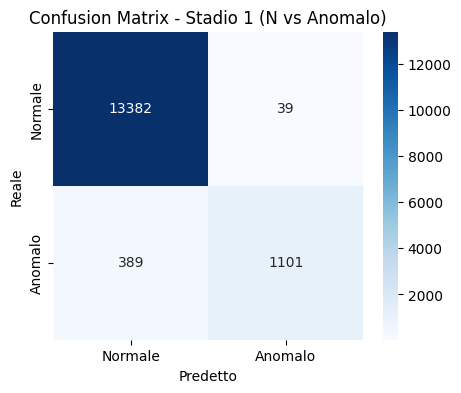

              precision    recall  f1-score   support

     Normale       0.97      1.00      0.98     13421
     Anomalo       0.97      0.74      0.84      1490

    accuracy                           0.97     14911
   macro avg       0.97      0.87      0.91     14911
weighted avg       0.97      0.97      0.97     14911



In [8]:
y_val_pred_s1 = (model_stadio1.predict([X_val_r, rr_val_norm]) > 0.5).astype(int).flatten()

cm_s1 = confusion_matrix(y_val_bin, y_val_pred_s1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_s1, annot=True, fmt='d', xticklabels=['Normale','Anomalo'], yticklabels=['Normale','Anomalo'], cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.title('Confusion Matrix - Stadio 1 (N vs Anomalo)')
plt.show()

print(classification_report(y_val_bin, y_val_pred_s1, target_names=['Normale','Anomalo']))

## 10. Stadio 2 -- Sotto-classificazione S/V/F/Q (RR interval + augmentation su F + Macro F1)

Filtriamo solo i segmenti realmente anomali, applichiamo augmentation su F, e monitoriamo Macro F1 invece di val_loss.

In [9]:
mask_anom_train = y_train_int != indice_N
mask_anom_val = y_val_int != indice_N

X_train_anom = X_train_r[mask_anom_train]
rr_train_anom = rr_train_norm[mask_anom_train]
X_val_anom = X_val_r[mask_anom_val]
rr_val_anom = rr_val_norm[mask_anom_val]

classi_anomale = sorted([c for c in classe_to_int if c != 'N'])
classe_to_int_s2 = {c: i for i, c in enumerate(classi_anomale)}
int_to_classe_s2 = {i: c for c, i in classe_to_int_s2.items()}
print('Mappa Stadio 2:', classe_to_int_s2)

y_train_s2 = np.array([classe_to_int_s2[int_to_classe[i]] for i in y_train_int[mask_anom_train]])
y_val_s2 = np.array([classe_to_int_s2[int_to_classe[i]] for i in y_val_int[mask_anom_val]])

for c, i in classe_to_int_s2.items():
    n = (y_train_s2 == i).sum()
    print(f'  {c}: {n} esempi nel training anomalo')

Mappa Stadio 2: {np.str_('F'): 0, np.str_('Q'): 1, np.str_('S'): 2, np.str_('V'): 3}
  F: 422 esempi nel training anomalo
  Q: 5973 esempi nel training anomalo
  S: 2336 esempi nel training anomalo
  V: 5282 esempi nel training anomalo


In [10]:
def augmenta_segmento(segmento, rng):
    aug = segmento.copy()
    shift = rng.integers(-5, 6)
    aug = np.roll(aug, shift)
    aug = aug + rng.normal(0, 0.03, size=aug.shape)
    fattore_scala = rng.uniform(0.9, 1.1)
    aug = aug * fattore_scala
    return aug

rng = np.random.default_rng(42)
indice_F_s2 = classe_to_int_s2['F']
idx_F_s2 = np.where(y_train_s2 == indice_F_s2)[0]
print(f'Esempi reali di F nel training anomalo: {len(idx_F_s2)}')

N_COPIE = 8
X_aug_list, rr_aug_list, y_aug_list = [], [], []

for idx in idx_F_s2:
    seg_orig = X_train_anom[idx, :, 0]
    rr_orig = rr_train_anom[idx]
    for _ in range(N_COPIE):
        X_aug_list.append(augmenta_segmento(seg_orig, rng))
        rr_aug_list.append(rr_orig)
        y_aug_list.append(indice_F_s2)

X_aug = np.array(X_aug_list).reshape(-1, X_train_anom.shape[1], 1)
rr_aug = np.array(rr_aug_list)
y_aug = np.array(y_aug_list)

X_train_s2_final = np.concatenate([X_train_anom, X_aug], axis=0)
rr_train_s2_final = np.concatenate([rr_train_anom, rr_aug], axis=0)
y_train_s2_final = np.concatenate([y_train_s2, y_aug], axis=0)

print(f'Training Stadio 2 dopo augmentation: {len(y_train_s2_final)} esempi (F: {(y_train_s2_final == indice_F_s2).sum()})')

Esempi reali di F nel training anomalo: 422
Training Stadio 2 dopo augmentation: 17389 esempi (F: 3798)


In [11]:
pesi_s2_arr = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_s2_final), y=y_train_s2_final)
class_weights_s2 = dict(zip(np.unique(y_train_s2_final), pesi_s2_arr))
print('Class weights Stadio 2:', class_weights_s2)

model_stadio2 = costruisci_modello_duale(X_train_r.shape[1], num_output=len(classi_anomale), attivazione_finale='softmax')

model_stadio2.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

macro_f1_cb_s2 = MacroF1Callback([X_val_anom, rr_val_anom], y_val_s2)
early_stop_s2 = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15, restore_best_weights=True)
reduce_lr_s2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_s2 = model_stadio2.fit(
    [X_train_s2_final, rr_train_s2_final], y_train_s2_final,
    validation_data=([X_val_anom, rr_val_anom], y_val_s2),
    epochs=60,
    batch_size=64,
    class_weight=class_weights_s2,
    callbacks=[macro_f1_cb_s2, early_stop_s2, reduce_lr_s2],
    verbose=1
)

Class weights Stadio 2: {np.int64(0): np.float64(1.144615587151132), np.int64(1): np.float64(0.7278168424577265), np.int64(2): np.float64(1.860980308219178), np.int64(3): np.float64(0.8230310488451344)}
Epoch 1/60
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8050 - loss: 0.7981 -- val_macro_f1: 0.1960
272/272 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9045 - loss: 0.5145 - val_accuracy: 0.6141 - val_loss: 1.3195 - val_macro_f1: 0.1960 - learning_rate: 3.0000e-04
Epoch 2/60
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9571 - loss: 0.2062 -- val_macro_f1: 0.2909
272/272 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9624 - loss: 0.1810 - val_accuracy: 0.6450 - val_loss: 1.2648 - val_macro_f1: 0.2909 - learning_rate: 3.0000e-04
Epoch 3/60
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9717 - loss: 0.1316 -- val_macro_f1: 0.4573
272/272 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9758 - loss: 0.1186 - val_accuracy: 0.6235 - val_loss: 0.8121 - val_ma

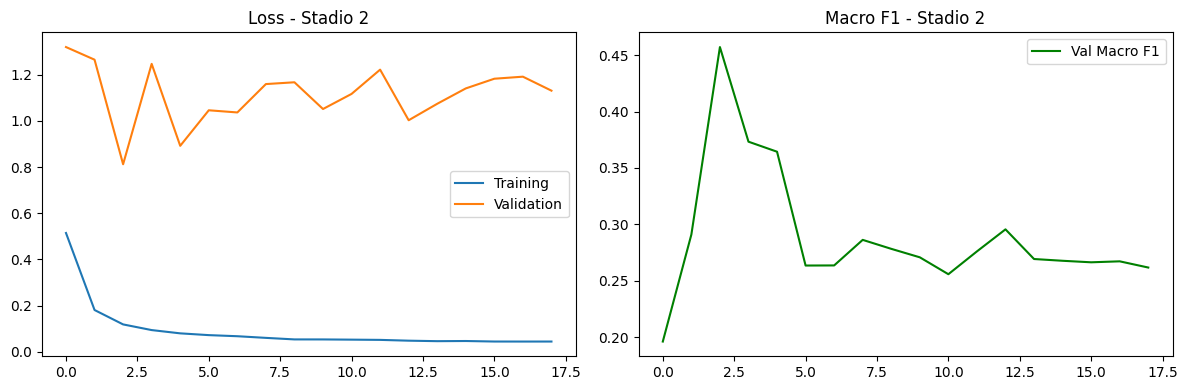

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


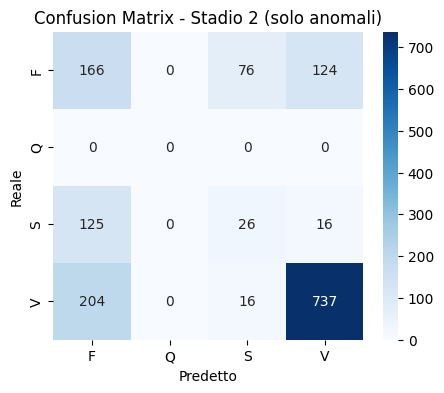

              precision    recall  f1-score   support

           F       0.34      0.45      0.39       366
           Q       0.00      0.00      0.00         0
           S       0.22      0.16      0.18       167
           V       0.84      0.77      0.80       957

    accuracy                           0.62      1490
   macro avg       0.35      0.34      0.34      1490
weighted avg       0.65      0.62      0.63      1490



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_s2.history['loss'], label='Training')
axes[0].plot(history_s2.history['val_loss'], label='Validation')
axes[0].set_title('Loss - Stadio 2')
axes[0].legend()
axes[1].plot(history_s2.history['val_macro_f1'], label='Val Macro F1', color='green')
axes[1].set_title('Macro F1 - Stadio 2')
axes[1].legend()
plt.tight_layout()
plt.show()

y_val_pred_s2 = np.argmax(model_stadio2.predict([X_val_anom, rr_val_anom]), axis=1)
nomi_s2 = [int_to_classe_s2[i] for i in range(len(classi_anomale))]

etichette_attese_s2 = list(range(len(classi_anomale)))

cm_s2 = confusion_matrix(y_val_s2, y_val_pred_s2, labels=etichette_attese_s2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_s2, annot=True, fmt='d', xticklabels=nomi_s2, yticklabels=nomi_s2, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.title('Confusion Matrix - Stadio 2 (solo anomali)')
plt.show()

print(classification_report(y_val_s2, y_val_pred_s2, labels=etichette_attese_s2, target_names=nomi_s2, zero_division=0))

## 11. Pipeline combinata -- Valutazione end-to-end su tutto il Validation Set

466/466 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


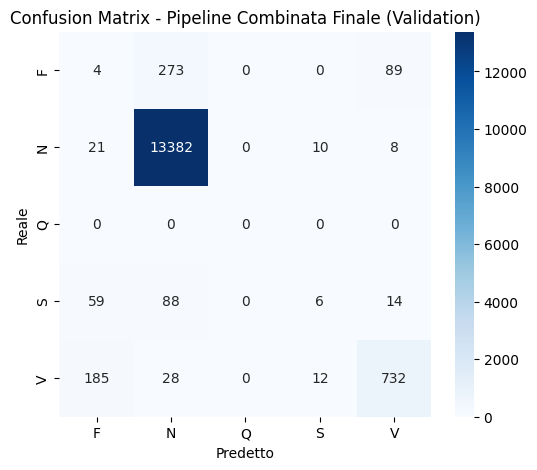

              precision    recall  f1-score   support

           F       0.01      0.01      0.01       366
           N       0.97      1.00      0.98     13421
           Q       0.00      0.00      0.00         0
           S       0.21      0.04      0.06       167
           V       0.87      0.76      0.81       957

    accuracy                           0.95     14911
   macro avg       0.41      0.36      0.37     14911
weighted avg       0.93      0.95      0.94     14911



In [19]:
pred_s1_val = (model_stadio1.predict([X_val_r, rr_val_norm]) > 0.5).astype(int).flatten()
pred_finale = np.full(len(y_val_int), indice_N)

idx_anomali_predetti = np.where(pred_s1_val == 1)[0]
if len(idx_anomali_predetti) > 0:
    X_sub = X_val_r[idx_anomali_predetti]
    rr_sub = rr_val_norm[idx_anomali_predetti]
    pred_s2_su_predetti = np.argmax(model_stadio2.predict([X_sub, rr_sub]), axis=1)
    for pos, idx in enumerate(idx_anomali_predetti):
        classe_lettera = int_to_classe_s2[pred_s2_su_predetti[pos]]
        pred_finale[idx] = classe_to_int[classe_lettera]

etichette_attese_finali = list(range(num_classi))

cm_finale = confusion_matrix(y_val_int, pred_finale, labels=etichette_attese_finali)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_finale, annot=True, fmt='d', xticklabels=nomi_classi_finali, yticklabels=nomi_classi_finali, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.title('Confusion Matrix - Pipeline Combinata Finale (Validation)')
plt.show()

print(classification_report(y_val_int, pred_finale, labels=etichette_attese_finali, target_names=nomi_classi_finali, zero_division=0))